In [31]:
import pymc
from magnus import NSFeas
import numpy as np
import matplotlib.pyplot as plt

In [32]:
R_GAS = 8.314 # J/K/mol
E_1 = 48_000 # J/mol
E_2 = 55_000 # J/mol

In [33]:
def theta_nominal():
    T_REF = 328.15
    k_1_ref = 8.84e-3 * 60 * 0.5 # 1/min
    k_2_ref = k_1_ref / 8
    theta_1 = k_1_ref * np.exp(E_1 / (R_GAS * T_REF))
    theta_2 = k_2_ref * np.exp(E_2 / (R_GAS * T_REF))

    return theta_1, theta_2

In [34]:
# initialize preexponentials
th_1, th_2 = theta_nominal()

# Feed concentrations
c_A_F, c_B_F, c_C_F = 11.28, 0, 0 # mol/L (pure benzene feed)

def model(x):
    T_1, tau_1, T_2, tau_2 = x[0], x[1], x[2], x[3]

    # NOTE: rho (recycle ratio) is kept constant to keep a 4-dim design space
    # TODO: set rho -> 0 and verify consistency with no recycle setup
    rho = 0

    k_1_R1 = th_1 * np.exp(-E_1  / (R_GAS * T_1)) # Reaction 1 in CSTR-1
    k_1_R2 = th_1 * np.exp(-E_1  / (R_GAS * T_2)) # Reaction 1 in CSTR-2
    k_2_R1 = th_2 * np.exp(-E_2  / (R_GAS * T_1)) # Reaction 2 in CSTR-1
    k_2_R2 = th_2 * np.exp(-E_2  / (R_GAS * T_2)) # Reaction 2 in CSTR-2

    gamma = 1 + k_2_R2 * tau_2
    delta = 1 + k_1_R2 * tau_2

    c_A_R1_denom = rho - delta * (1 + k_1_R1 * tau_1)
    c_A_R1 = c_A_F * (rho - 1) * delta / c_A_R1_denom
    c_A_R2 = c_A_R1 / delta

    c_B_R1_num_1 = rho * k_1_R2 * c_A_R2 * tau_2
    c_B_R1_num_2 = gamma * (c_B_F * (1-rho) + k_1_R1 * c_A_R1 * tau_1)
    c_B_R1_denom = gamma * (1 + k_2_R1 * tau_1) - rho
    c_B_R1 = (c_B_R1_num_1 + c_B_R1_num_2) / c_B_R1_denom
    c_B_R2 = (c_B_R1 + k_1_R2 * c_A_R2 * tau_2) / gamma

    c_C_R1 = c_C_F - 1 / (rho - 1)  * (k_2_R1 * c_B_R1 * tau_1 + k_2_R2 * c_B_R2 * tau_2 * rho)
    c_C_R2 = c_C_R1 + k_2_R2 * c_B_R2 * tau_2

    return [c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2]

In [35]:
DAG = pymc.FFGraph()
DAG.options.MAXTHREAD = 1

T_1, tau_1 = DAG.add_var('T_1'), DAG.add_var('tau_1')
T_2, tau_2 = DAG.add_var('T_2'), DAG.add_var('tau_2')

op = pymc.FFCustom()
op.set_D_eval(model)
# applying the operation adds nodes to DAG
outs = op(ndep=6, var=[T_1, tau_1, T_2, tau_2], uid=0)
c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2 = outs[0], outs[1], outs[2], outs[3], outs[4], outs[5]
DAG


DAG VARIABLES:
  T_1	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  tau_1	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  T_2	 => { Z0 Z1 Z2 Z3 Z4 Z5 }
  tau_2	 => { Z0 Z1 Z2 Z3 Z4 Z5 }

DAG INTERMEDIATES:
  Z0	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[0]	 => { }
  Z1	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[1]	 => { }
  Z2	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[2]	 => { }
  Z3	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[3]	 => { }
  Z4	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[4]	 => { }
  Z5	<=  Custom[0]( T_1, tau_1, T_2, tau_2 )	[5]	 => { }

In [36]:
# Setup nested sampler
NS = NSFeas()
NS.options.MAXTHREAD = 1           # Python callback + GIL: must be 1
NS.options.DISPLEVEL = 1           # console verbosity
NS.options.DISPITER  = 25          # rows per N iterations in table (cosemtic)
NS.options.NUMLIVE   = 8192       # #Live Points
NS.options.NUMPROP   = 256        # Proposals per iteration
NS.options.MAXITER   = 0           # iterate until complete (hard iteration limit else)

NS.set_dag(DAG)
# contols for variables and bounds
NS.set_control([T_1, tau_1, T_2, tau_2], [298.15, 2, 298.15, 2], [353.15, 30, 353.15, 30])
NS.set_constraint([c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - 0.05,
                   0.55 - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2), 
                   0.70 - (1 - c_A_R2 / c_A_F)])
NS.setup()
NS.sample()
NS.stats.display()


** INITIALIZING LIVE POINTS (8192)      0.05 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.2265e-01   574        0     3.0000e-01


     25     2.4991e-01  1038     4735     2.6726e-01
     50     1.5002e-01  1480     7715     2.4850e-01
     75     1.0114e-01  1937     9884     2.3569e-01
    100     7.3699e-02  2397    11607     2.2598e-01
    125     5.5484e-02  2854    13027     2.1828e-01
    150     4.3120e-02  3309    14266     2.1177e-01
    175     3.3863e-02  3795    15365     2.0617e-01
    200     2.6531e-02  4295    16391     2.0107e-01
    225     2.0689e-02  4810    17298     1.9666e-01
    250     1.6045e-02  5330    18150     1.9261e-01
    275     1.2084e-02  5863    18943     1.8892e-01
    300     8.5544e-03  6409    19673     1.8558e-01
    325     4.6346e-03  7140    20559     1.8161e-01
    350     1.7537e-04  8152    21644     1.7687e-01
    352    -1.7779e-05  8197    21689     1.7667e-01

** EVALUATIONS:      98048 (0 FAILED)
** WALL TIME:         3.10 SEC


In [37]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "plots" / "tools"))
from trellis import trellis_plot

In [38]:
# NS.livepoints returns: (points[N, nu],  crit[N, 1],  prob[N, 1],  aux[N, 1])
live_pts, live_feas, *_ = NS.live_points
dead_pts, dead_feas, *_ = NS.dead_points

panel counts (rows = $\tau_2$ [min] high->low, cols = $\tau_1$ [min] low->high):
[[4382 2768 1929]
 [4876 3086 2128]
 [4984 3383 2345]]
sum of panels = 29881   total points = 29881


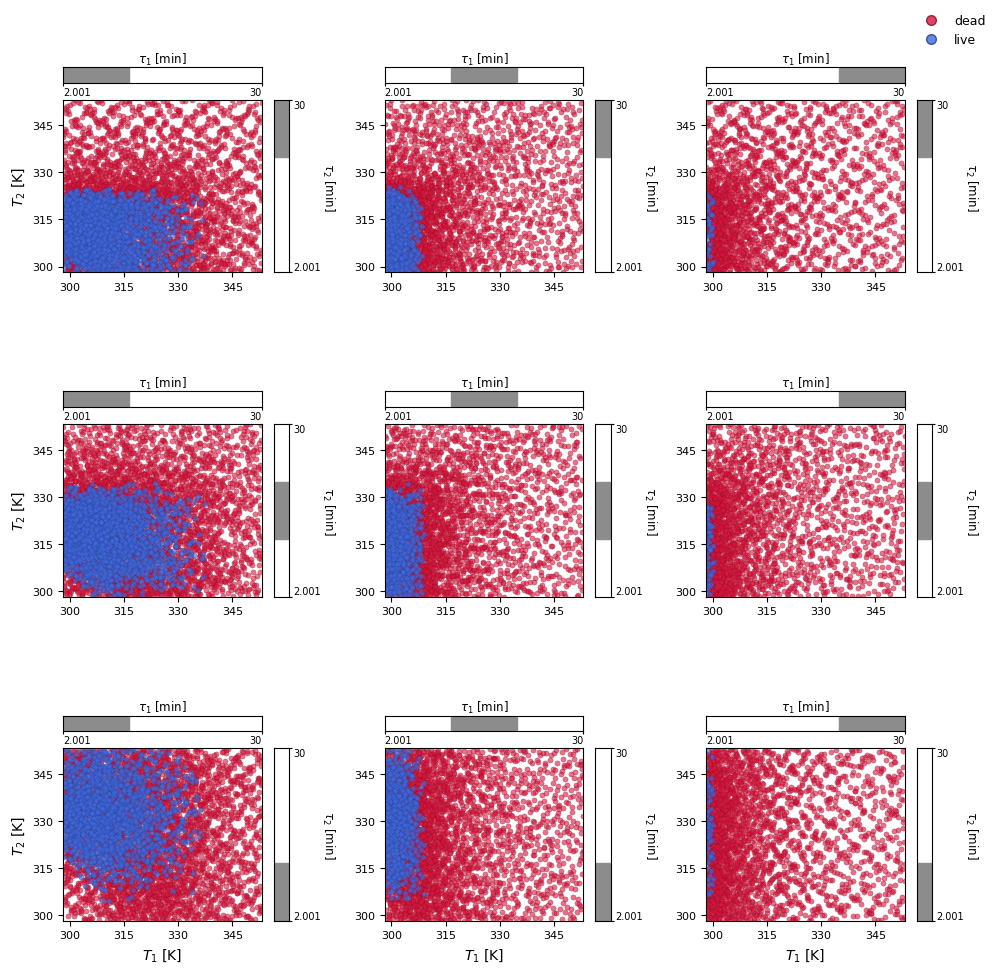

In [39]:
fig = trellis_plot(
    [dead_pts[:, 0], live_pts[:, 0]],   # T_1
    [dead_pts[:, 2], live_pts[:, 2]],   # T_2
    [dead_pts[:, 1], live_pts[:, 1]],   # tau_1
    [dead_pts[:, 3], live_pts[:, 3]],   # tau_2
    x_label="$T_1$ [K]",
    y_label=r"$T_2$ [K]",
    col_label=r"$\tau_1$ [min]",
    row_label=r"$\tau_2$ [min]",
    colors=["crimson", "royalblue"],
    labels=["dead", "live"],
)

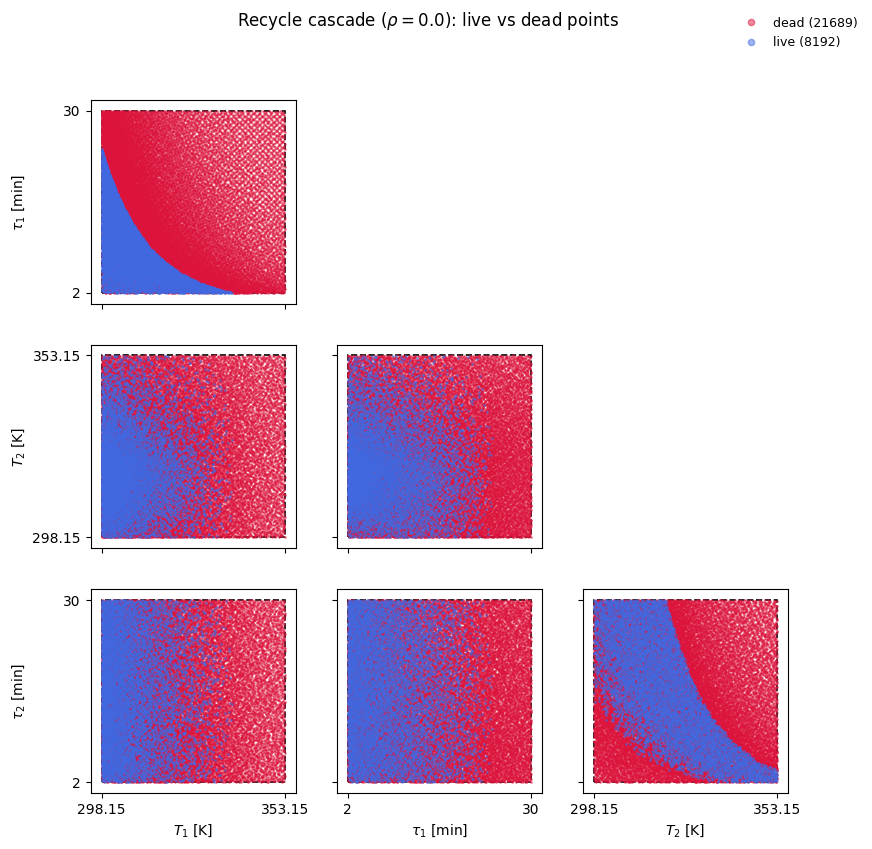

In [40]:
from corner import corner_plot

fig = corner_plot(
    [  # painter's order: dead below, live (feasible) on top
        dict(data=dead_pts, color="crimson", ms=2, alpha=0.5, label=f"dead ({len(dead_pts)})"),
        dict(data=live_pts, color="royalblue", ms=2, alpha=0.5, label=f"live ({len(live_pts)})"),
    ],
    labels=[r"$T_1$ [K]", r"$\tau_1$ [min]", r"$T_2$ [K]", r"$\tau_2$ [min]"],
    bounds=[(298.15, 353.15), (2, 30), (298.15, 353.15), (2, 30)],
    legend=True,
    title=r"Recycle cascade ($\rho = 0$): live vs dead points",
)